# ANALYSE EXPLORATOIRE & IMPACT DATA CLEANING

## La base de donnée utilisée se trouve ici [--> cliquez](https://drive.google.com/drive/folders/1nJpCoLpEbv_JemgYdl6uX5GtntqOu21C)

### Notre objectif est :
*  d'analyser le dataset stroke
*  d'identifier des problèmes de qualité des données
*  d'appliquer différentes méthodes de traitement
*  de comparer les résultats entre groupes

# PARTIE 1 : INSPECTION

In [1]:
# importons les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# chargeons le dataset
df = pd.read_csv("dataset_stroke_nouv.csv")
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,NaN,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  4856 non-null   float64
 9   bmi                4390 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### 1. Identification

In [4]:
# nombre de lignes et de colonnes
print("Nombre de lignes et de colonnes:", df.shape)

Nombre de lignes et de colonnes: (5110, 12)


In [5]:
# types de variables
print("Types de variables :\n\n", df.dtypes)



Types de variables :

 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


### 2. Détection

In [6]:
# valeurs manquantes
print("Valeurs manquantes :\n", df.isnull().sum())

Valeurs manquantes :
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level    254
bmi                  720
smoking_status         0
stroke                 0
dtype: int64


In [7]:
# valeurs suspectes
df.loc[ : , df.columns != "id"].describe()


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,4856.000000,4390.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.274014,28.930342,0.048728
std,22.612647,0.296607,0.226063,45.370994,7.801910,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.407500,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.990000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.320000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
# aperçu de smoking_status
print(df['smoking_status'].value_counts())

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


## Avant transformations (age, bmi et avg_glucose_level)

---



##### bmi (distribution, boxplot, describe)

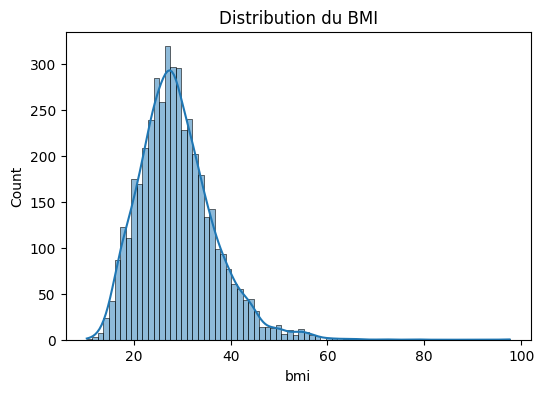

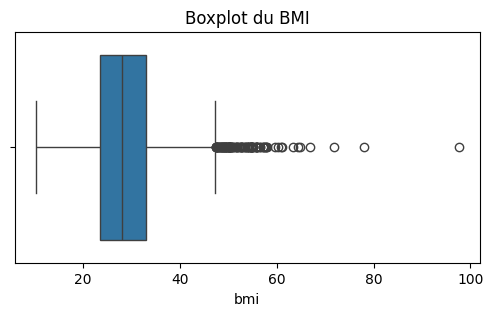

count    4390.000000
mean       28.930342
std         7.801910
min        10.300000
25%        23.600000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64


In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True)
plt.title("Distribution du BMI")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot du BMI")
plt.show()

print(df['bmi'].describe())

##### Age (distribution, boxplot, describe)

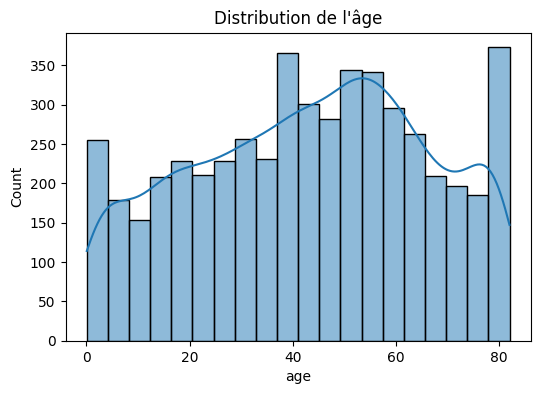

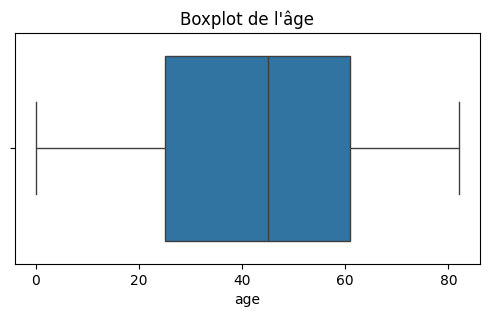

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64


In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Distribution de l'âge")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['age'])
plt.title("Boxplot de l'âge")
plt.show()

print(df['age'].describe())

##### avg_glucose_level (distribution, boxplot, describe)

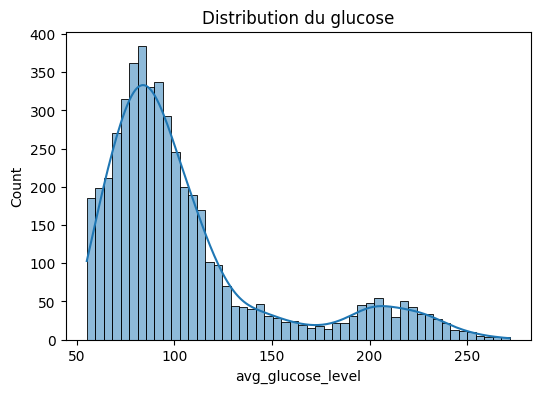

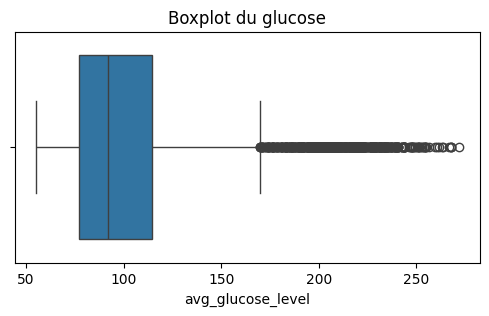

count    4856.000000
mean      106.274014
std        45.370994
min        55.120000
25%        77.407500
50%        91.990000
75%       114.320000
max       271.740000
Name: avg_glucose_level, dtype: float64


In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['avg_glucose_level'], kde=True)
plt.title("Distribution du glucose")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['avg_glucose_level'])
plt.title("Boxplot du glucose")
plt.show()

print(df['avg_glucose_level'].describe())

## Questions

##### -La variable à prédire est : stroke
##### -Les variables numériques sont :
- id             
- age
- hypertension
- heart_disease
- avg_glucose_level    
- bmi   
- stroke               
#### Oui le dataset contient des anomalies telles que:
- l'id est de type int
- il y a des valeurs manquantes NaN
- la variable smoking_status peut prendre la valeur Unknown
- la variable age a une valeur minimum de 0



# PARTIE 2 : IDENTIFICATION DES PROBLÈMES

###  DATASET STROKE

##### Valeurs manquantes

- BMI

In [12]:
print("Nombre de valeurs manquantes dans BMI:",df['bmi'].isna().sum())

Nombre de valeurs manquantes dans BMI: 720


- avg_glucose_level

In [13]:
print("Nombre de valeur manquante dans avg_glucose_level:",df['avg_glucose_level'].isna().sum())

Nombre de valeur manquante dans avg_glucose_level: 254


### Questions

##### La différence entre valeur manquante et erronée
- valeur manquante -> valeur inconnue, non exploitable
- valeur erronée -> valeur présente non réaliste susceptible de fausser les résultats

# PARTIE 3 : PRÉPARATION DES DONNÉES

### STROKE

In [14]:

# aperçu de smoking_status
print(df['smoking_status'].value_counts())

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [15]:
# transformons les unknown de smoking_status en NaN
df['smoking_status'] = df['smoking_status'].replace('Unknown', np.nan)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,NaN,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,NaN,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,NaN,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  4856 non-null   float64
 9   bmi                4390 non-null   float64
 10  smoking_status     3566 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [17]:
print(df['smoking_status'].value_counts())

smoking_status
never smoked       1892
formerly smoked     885
smokes              789
Name: count, dtype: int64


##### Observation
- il y a 254 valeurs manquantes dans avg_glucose_level
- il y a 720 valeurs manquantes dans BMI
- en transformant smoking_status en NaN nous voyons qu'il y a 1544 Unknown dans smoking_status

### Analyse
- les valeurs manquantes sont uniquement dans avg_glucose_level, bmi et smoking_status
- la variable smoking_status contient le plus de valeurs manquantes, suivi de bmi puis de avg_glucose_level


# PARTIE 4 : TRAITEMENT DES VALEURS MANQUANTES

In [18]:
# avant le traitement

In [19]:
df['bmi'].describe()

count    4390.000000
mean       28.930342
std         7.801910
min        10.300000
25%        23.600000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [20]:
df['avg_glucose_level'].describe()

count    4856.000000
mean      106.274014
std        45.370994
min        55.120000
25%        77.407500
50%        91.990000
75%       114.320000
max       271.740000
Name: avg_glucose_level, dtype: float64

In [21]:
print(df['smoking_status'].value_counts())

smoking_status
never smoked       1892
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [22]:
# traitement

In [23]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

print(df['bmi'].isnull().sum())

0


In [24]:
df['avg_glucose_level'] = df['avg_glucose_level'].fillna(df['avg_glucose_level'].mean())

print(df['avg_glucose_level'].isnull().sum())

0


In [25]:
# changeons les NaN se trouvant dans la colonne smoking_status par le mode
mode_smoking_status = df['smoking_status'].mode()[0]

df['smoking_status'] = df['smoking_status'].replace('NaN', mode_smoking_status)

In [26]:
# après le traitement

In [27]:
df['bmi'].describe()

count    5110.000000
mean       28.930342
std         7.231290
min        10.300000
25%        24.400000
50%        28.930342
75%        32.200000
max        97.600000
Name: bmi, dtype: float64

In [28]:
df['avg_glucose_level'].describe()

count    5110.000000
mean      106.274014
std        44.228780
min        55.120000
25%        78.042500
50%        93.670000
75%       112.522500
max       271.740000
Name: avg_glucose_level, dtype: float64

In [29]:
print("Le mot le plus fréquent dans smoking_status (mode) est:", mode_smoking_status + "\n")
print(df['smoking_status'].value_counts())

Le mot le plus fréquent dans smoking_status (mode) est: never smoked

smoking_status
never smoked       1892
formerly smoked     885
smokes              789
Name: count, dtype: int64


### Questions obligatoires (tous groupes)

1.  Combien de valeurs ont été modifiées ?
- 720(bmi) + 254 (avg_glucose_level) + 1544 (smoking_status) = 2518
2.  Combien de données ont été perdues ?
- 0
3.  Votre méthode modifie-t-elle fortement le dataset ?
- on observe que pour:
  - le bmi: moyenne = médiane (la médiane a augmenté)
  - le avg_glucose_level: moyenne toujours > médiane (la médiane a augmenté)
  - le smoking_status: l'effectif de la valeur 'never smoked' a augmenté
- on peut donc en déduire que notre méthode modifie légèrement le dataset
4.  Cette méthode vous semble-t-elle réaliste ?
- Oui, cette méthode nous semble réaliste car elle est intuitive. Aussi, les descriptions statistiques des donnnées conservent leur cohérence après l'application de celle-ci.

# PARTIE 5 : ANALYSE UNIVARIÉE

## Après transformations (age, bmi et avg_glucose_level)

##### bmi (distribution, dispersion, valeurs extrêmes)

In [30]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.274014,28.930342,0.048728
std,21161.721625,22.612647,0.296607,0.226063,44.228780,7.231290,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,78.042500,24.400000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,93.670000,28.930342,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,112.522500,32.200000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


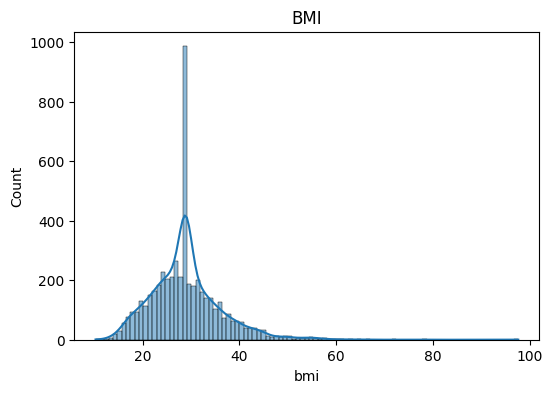

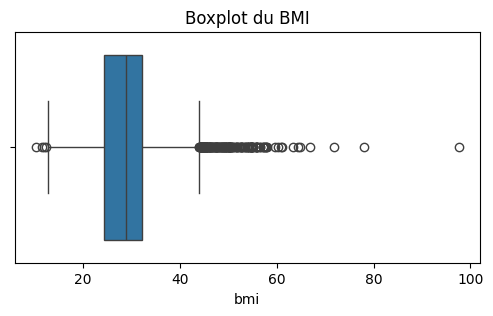

count    5110.000000
mean       28.930342
std         7.231290
min        10.300000
25%        24.400000
50%        28.930342
75%        32.200000
max        97.600000
Name: bmi, dtype: float64


In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True)
plt.title("BMI")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot du BMI")
plt.show()

print(df['bmi'].describe())

##### Age (distribution, dispersion, valeurs extrêmes)

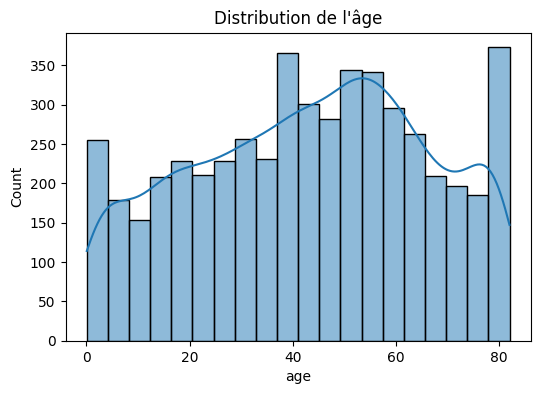

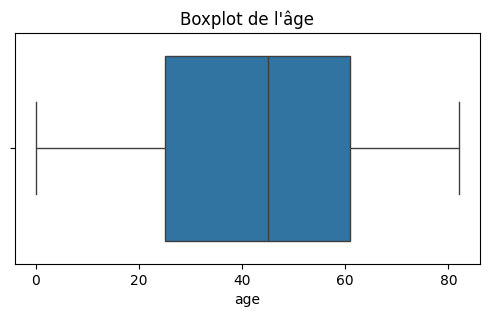

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64


In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Distribution de l'âge")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['age'])
plt.title("Boxplot de l'âge")
plt.show()

print(df['age'].describe())

##### avg_glucose_level (distribution, dispersion, valeurs extrêmes)

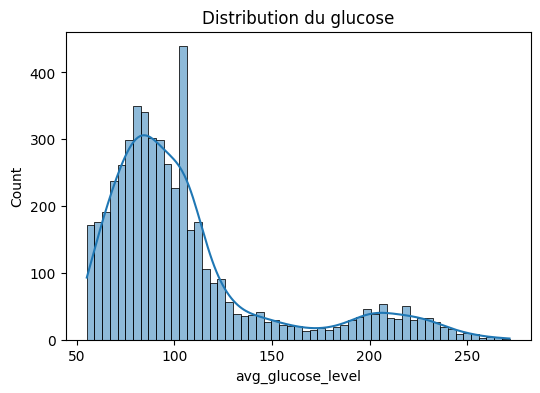

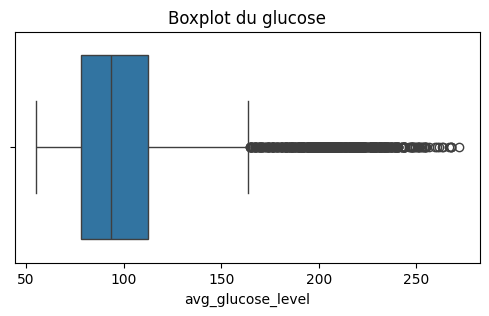

count    5110.000000
mean      106.274014
std        44.228780
min        55.120000
25%        78.042500
50%        93.670000
75%       112.522500
max       271.740000
Name: avg_glucose_level, dtype: float64


In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df['avg_glucose_level'], kde=True)
plt.title("Distribution du glucose")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['avg_glucose_level'])
plt.title("Boxplot du glucose")
plt.show()

print(df['avg_glucose_level'].describe())

Questions
-  Les distributions ont-elles changé après traitement ?
-  Les valeurs extrêmes sont-elles affectées ?


# PARTIE 6 : ANALYSE BIVARIÉE

In [34]:
# Notre variable cible
var_cible = df['stroke']

#### Stroke et age

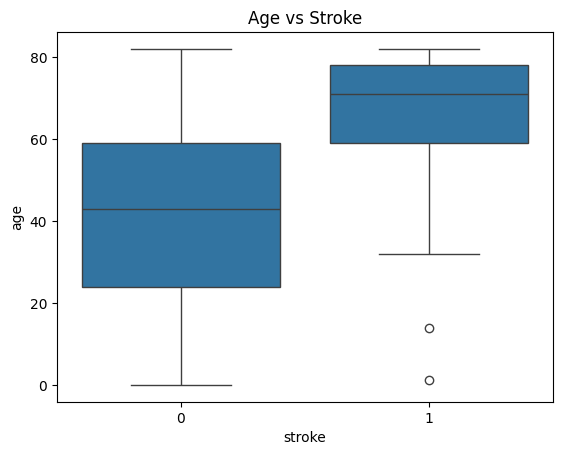

In [35]:
sns.boxplot(x=var_cible, y=df['age'])
plt.title("Age vs Stroke")
plt.show()

#### Stroke et bmi

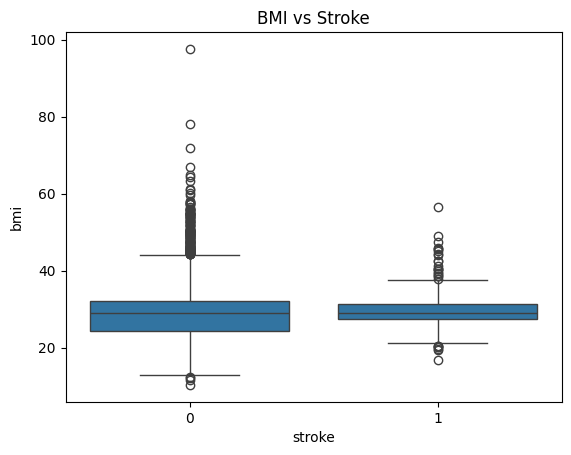

In [36]:
sns.boxplot(x=var_cible, y=df['bmi'])
plt.title("BMI vs Stroke")
plt.show()

#### Stroke et avg_glucose_level

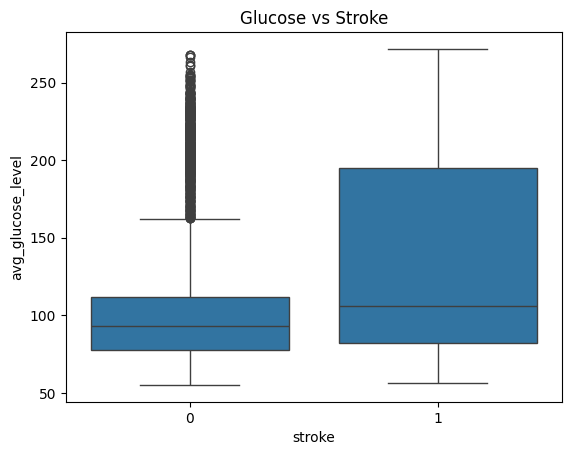

In [37]:
sns.boxplot(x=var_cible, y=df['avg_glucose_level'])
plt.title("Glucose vs Stroke")
plt.show()

Text(0.5, 1.0, 'Matrice de corrélation')

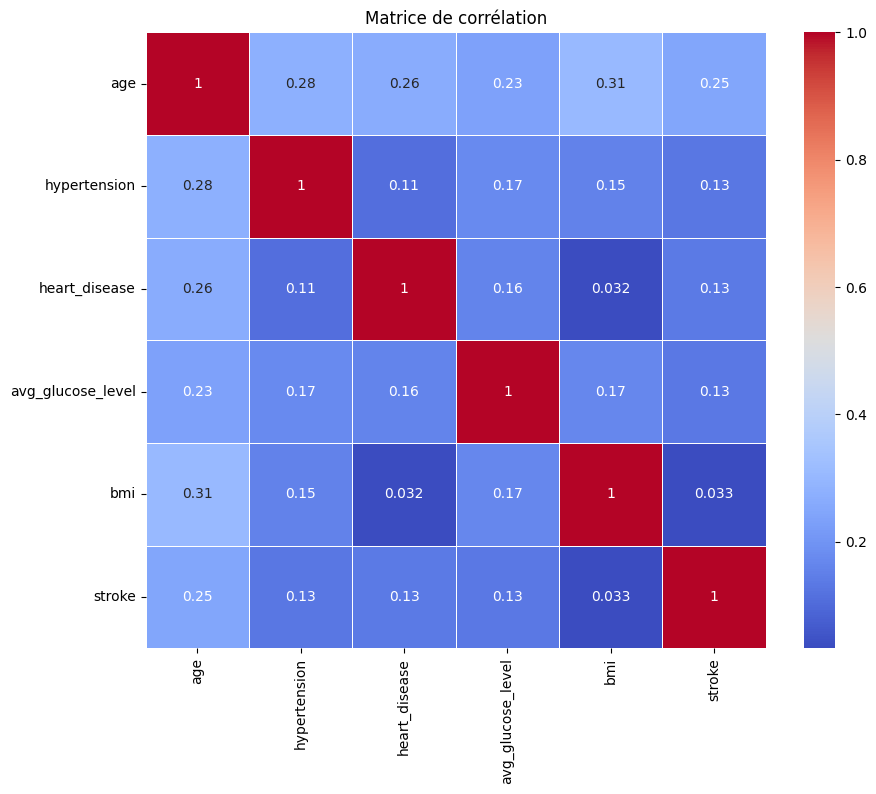

In [38]:
#matrice de corrélation avec uniquement les variables explicatives numériques sans id
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df = numerical_df.drop(columns=['id'])

correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Matrice de corrélation")